# Тимски проект: Споредба на алгоритмите за предвидување на временски серии
**Dataset:** PJME Hourly Energy Consumption

**Студенти:**

*   Амел Махмутовиќ (203100)
*   Христина Степаноска (183007)
*   Михаела Николовска (183014)




## 1. Вовед и опис на множеството
Во оваа тетратка се анализира часовната потрошувачка на електрична енергија користејќи го множеството податоци PJME Hourly Energy Consumption. Целта на анализата е да се изгради модел за предвидување на идната побарувачка на електрична енергија и да се направи споредба помеѓу различни пристапи за предвидување: базични модели, класични модели за временски серии и модели од машинско учење.

Множеството податоци ги содржи следните променливи:

*   Datetime – временска ознака на часовно ниво
*   PJME_MW – потрошувачка на електрична енергија изразена во мегавати (MW)

In [ ]:
from google.colab import drive, files

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from prophet import Prophet

import xgboost as xgb
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

import warnings
warnings.filterwarnings('ignore')

In [ ]:

BASE_PATH = "/content/drive/MyDrive/hourly-energy-consumption/"

# Model hyperparameters
HORIZON = 168  # Forecast 168 hours (1 week)
N_LAGS = 24   # Use 24 hours of lags
SEASON_PERIOD = 24  # Hourly data has 24-hour daily seasonality

# Random Forest
RF_N_ESTIMATORS = 100
RF_MAX_DEPTH = 15
RF_RANDOM_STATE = 42

# XGBoost
XGB_N_ESTIMATORS = 300
XGB_LEARNING_RATE = 0.05
XGB_MAX_DEPTH = 6

# LightGBM
LGBM_N_ESTIMATORS = 300
LGBM_LEARNING_RATE = 0.05
LGBM_MAX_DEPTH = 6

In [ ]:
def calculate_metrics(y_true, y_pred, model_name="Model"):
    """
    Calculate RMSE, MAE, and MAPE for model evaluation.
    """
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)

    # MAPE calculation with safety for zero values
    mask = y_true != 0
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

    print(f"\n{model_name} Performance:")
    print(f"  RMSE: {rmse:,.2f}")
    print(f"  MAE:  {mae:,.2f}")
    print(f"  MAPE: {mape:.2f}%")

    return {"RMSE": rmse, "MAE": mae, "MAPE": mape}

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 2. Вчитување и препроцесирање на податоците

Во оваа секција се вчитуваат податоците и се вршат основни трансформации за подготовка на временската серија.

In [ ]:
print("📥 Loading data...")

df = pd.read_csv(BASE_PATH + 'PJME_hourly.csv')

# Convert to datetime and set as index
df['Datetime'] = pd.to_datetime(df['Datetime'])
df = df.set_index('Datetime').sort_index()

# Remove duplicates and set frequency
df = df[~df.index.duplicated(keep='first')]
df = df.asfreq('h')

print(f"✅ Data loaded: {df.shape}")
print(df.head())

📥 Loading data...
✅ Data loaded: (145392, 1)
                     PJME_MW
Datetime                    
2002-01-01 01:00:00  30393.0
2002-01-01 02:00:00  29265.0
2002-01-01 03:00:00  28357.0
2002-01-01 04:00:00  27899.0
2002-01-01 05:00:00  28057.0


In [ ]:
print("\n" + "="*60)
print("📊 DATASET OVERVIEW")
print("="*60)

print(f"Missing values before cleaning: {df.isna().sum().sum()}")

df = df.dropna()

print(f"Missing values after cleaning: {df.isna().sum().sum()}")
print(f"\nFinal dataset shape: {df.shape}\n")

df.info()
print()
print(df.describe())



📊 DATASET OVERVIEW
Missing values before cleaning: 30
Missing values after cleaning: 0

Final dataset shape: (145362, 1)

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 145362 entries, 2002-01-01 01:00:00 to 2018-08-03 00:00:00
Data columns (total 1 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   PJME_MW  145362 non-null  float64
dtypes: float64(1)
memory usage: 2.2 MB

             PJME_MW
count  145362.000000
mean    32080.510780
std      6463.866507
min     14544.000000
25%     27573.000000
50%     31421.000000
75%     35650.000000
max     62009.000000


In [ ]:
#df['Datetime'] = pd.to_datetime(df['Datetime'])
#df = df.set_index('Datetime').sort_index()

In [ ]:
df = df[~df.index.duplicated(keep='first')]
df = df.asfreq('h')

In [ ]:
df.isna().sum()

,0
PJME_MW,30


In [ ]:
df = df.dropna()

In [ ]:
df

,PJME_MW
Datetime,
2002-01-01 01:00:00,30393.0
2002-01-01 02:00:00,29265.0
2002-01-01 03:00:00,28357.0
2002-01-01 04:00:00,27899.0
2002-01-01 05:00:00,28057.0
...,...
2018-08-02 20:00:00,44057.0
2018-08-02 21:00:00,43256.0
2018-08-02 22:00:00,41552.0


In [ ]:
df.isna().sum()

,0
PJME_MW,0


In [ ]:
df.describe()

,PJME_MW
count,145362.000000
mean,32080.510780
std,6463.866507
min,14544.000000
25%,27573.000000
50%,31421.000000
75%,35650.000000
max,62009.000000


## 3. Експлораторна анализа на податоците (EDA)

EDA се користи за подобро разбирање на временската серија. Се анализираат трендовите, дневната/неделната сезоналност и влијанието на работни денови vs викенди.


### 3.1 Преглед на целата временска серија



📈 KEY STATISTICS
Shape: (145362, 1)
Date range: 2002-01-01 01:00:00 to 2018-08-03 00:00:00
Total hours: 145,362

Energy Consumption Statistics:
count    145362.000000
mean      32080.510780
std        6463.866507
min       14544.000000
25%       27573.000000
50%       31421.000000
75%       35650.000000
max       62009.000000
Name: PJME_MW, dtype: float64


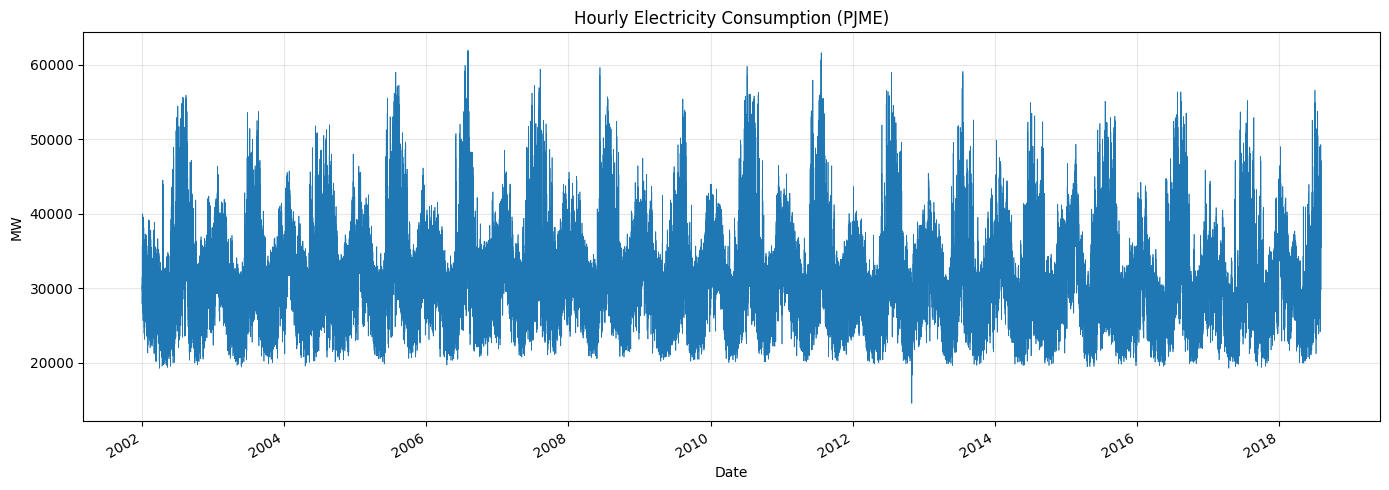

In [ ]:
print("\n" + "="*60)
print("📈 KEY STATISTICS")
print("="*60)
print(f"Shape: {df.shape}")
print(f"Date range: {df.index.min()} to {df.index.max()}")
print(f"Total hours: {len(df):,}")
print(f"\nEnergy Consumption Statistics:")
print(df['PJME_MW'].describe())

plt.figure(figsize=(14, 5))
df['PJME_MW'].plot(title='Hourly Electricity Consumption (PJME)', linewidth=0.5)
plt.ylabel('MW')
plt.xlabel('Date')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

###3.2 Преглед на една недела

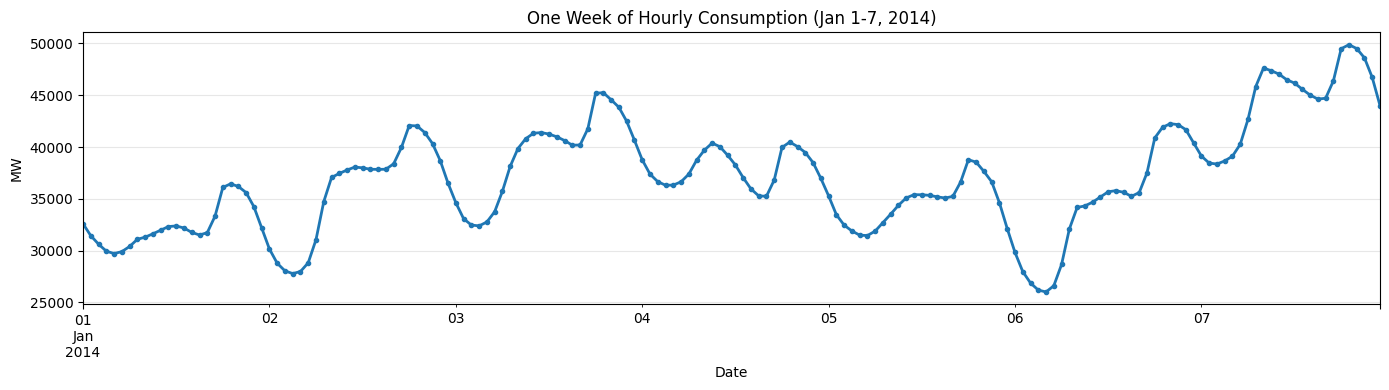

In [ ]:
sample_week = df.loc['2014-01-01':'2014-01-07', 'PJME_MW']

plt.figure(figsize=(14, 4))
sample_week.plot(linewidth=2, marker='o', markersize=3)
plt.title('One Week of Hourly Consumption (Jan 1-7, 2014)')
plt.ylabel('MW')
plt.xlabel('Date')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

###3.3 Просечна потрошувачка по час

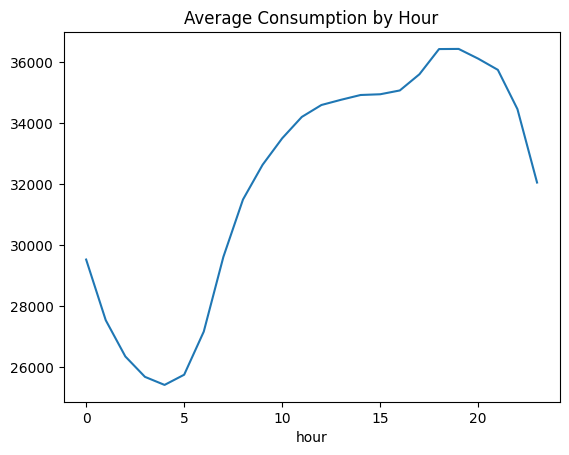

In [ ]:
df['hour'] = df.index.hour
df.groupby('hour')['PJME_MW'].mean().plot(title='Average Consumption by Hour')
plt.show()

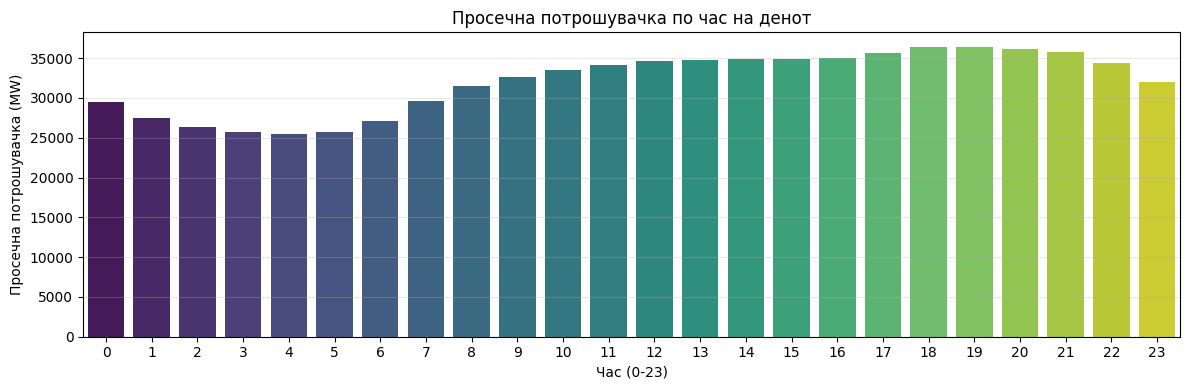


Пик час: 19:00 (36426.63 MW)
Најнизок час: 4:00 (25414.92 MW)


In [ ]:
# Add hour feature
df['hour'] = df.index.hour

# Calculate hourly average
hourly_avg = df.groupby('hour')['PJME_MW'].mean()

# Plot
plt.figure(figsize=(12, 4))
sns.barplot(x=hourly_avg.index, y=hourly_avg.values, palette='viridis')
plt.title('Просечна потрошувачка по час на денот')
plt.xlabel('Час (0-23)')
plt.ylabel('Просечна потрошувачка (MW)')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nПик час: {hourly_avg.idxmax()}:00 ({hourly_avg.max():.2f} MW)")
print(f"Најнизок час: {hourly_avg.idxmin()}:00 ({hourly_avg.min():.2f} MW)")

###3.4 Просечна потрошувачка по ден во неделата

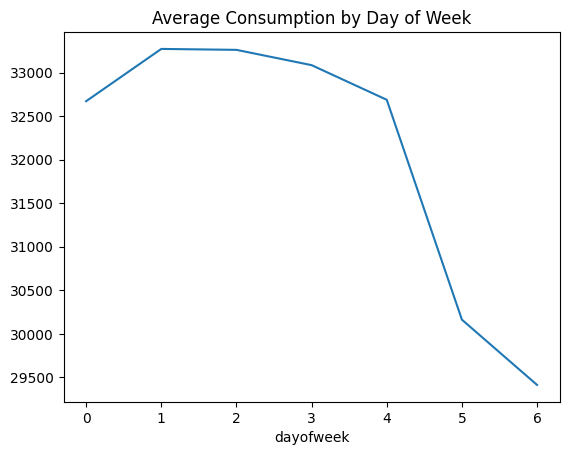

In [ ]:
df['dayofweek'] = df.index.dayofweek
df.groupby('dayofweek')['PJME_MW'].mean().plot(title='Average Consumption by Day of Week')
plt.show()

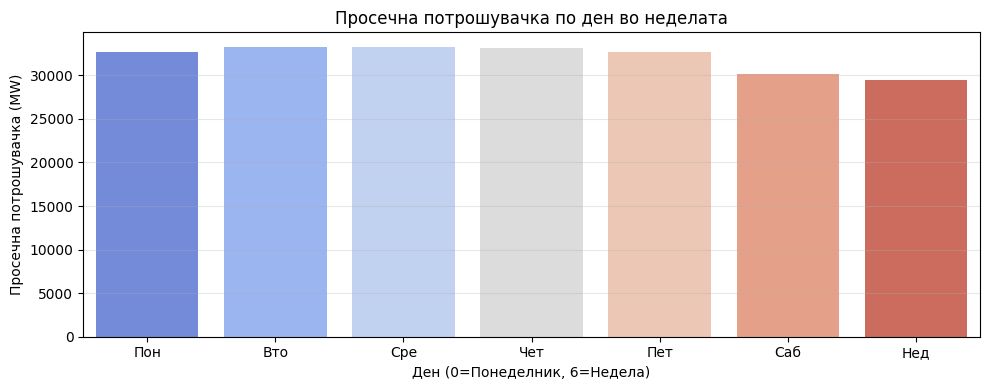

In [ ]:
# Add day of week feature
df['dayofweek'] = df.index.dayofweek

# Calculate daily average
daily_avg = df.groupby('dayofweek')['PJME_MW'].mean()

# Plot
plt.figure(figsize=(10, 4))
sns.barplot(x=daily_avg.index, y=daily_avg.values, palette='coolwarm')
plt.title('Просечна потрошувачка по ден во неделата')
plt.xlabel('Ден (0=Понеделник, 6=Недела)')
plt.ylabel('Просечна потрошувачка (MW)')
plt.xticks(range(7), ['Пон', 'Вто', 'Сре', 'Чет', 'Пет', 'Саб', 'Нед'])
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

###3.5 Просечна потрошувачка по месец

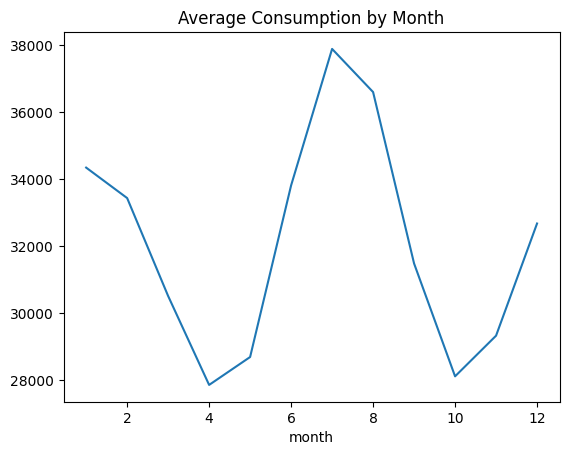

In [ ]:
df['month'] = df.index.month
df.groupby('month')['PJME_MW'].mean().plot(title='Average Consumption by Month')
plt.show()

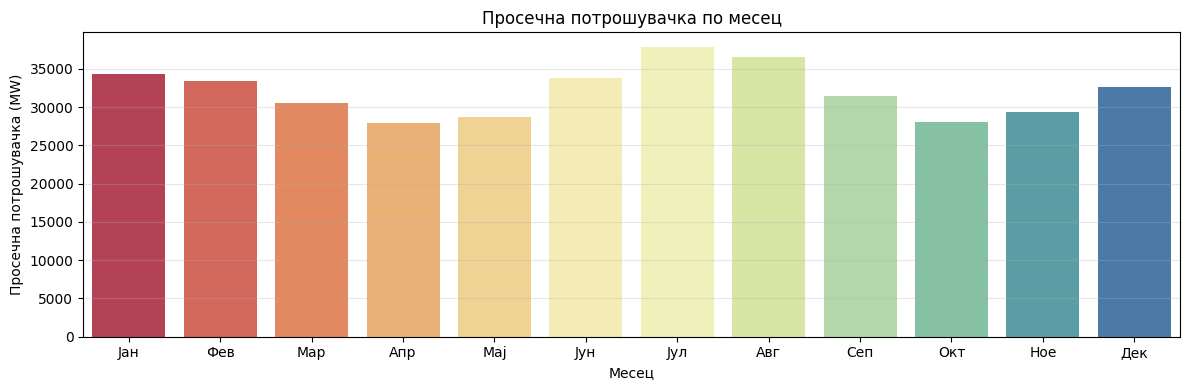


Пик месец: 7 (37881.97 MW)
Најнизок месец: 4 (27863.34 MW)


In [ ]:
df['month'] = df.index.month

monthly_avg = df.groupby('month')['PJME_MW'].mean()

# Plot
plt.figure(figsize=(12, 4))
sns.barplot(x=monthly_avg.index, y=monthly_avg.values, palette='Spectral')
plt.title('Просечна потрошувачка по месец')
plt.xlabel('Месец')
plt.ylabel('Просечна потрошувачка (MW)')
plt.xticks(range(12), ['Јан', 'Фев', 'Мар', 'Апр', 'Мај', 'Јун',
                        'Јул', 'Авг', 'Сеп', 'Окт', 'Ное', 'Дек'])
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nПик месец: {monthly_avg.idxmax()} ({monthly_avg.max():.2f} MW)")
print(f"Најнизок месец: {monthly_avg.idxmin()} ({monthly_avg.min():.2f} MW)")

###3.6 Долгорочен тренд

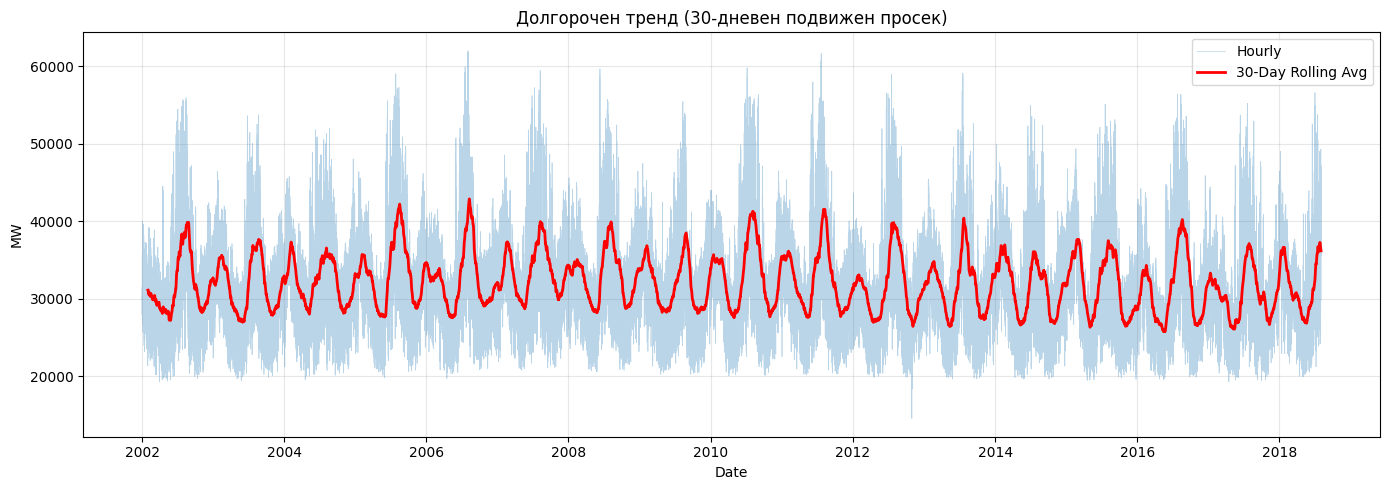

In [ ]:
rolling_30d = df['PJME_MW'].rolling(24*30).mean()

plt.figure(figsize=(14, 5))
plt.plot(df.index, df['PJME_MW'], alpha=0.3, linewidth=0.5, label='Hourly')
plt.plot(df.index, rolling_30d, linewidth=2, color='red', label='30-Day Rolling Avg')
plt.title('Долгорочен тренд (30-дневен подвижен просек)')
plt.ylabel('MW')
plt.xlabel('Date')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

###3.7 Работни денови vs Викенди

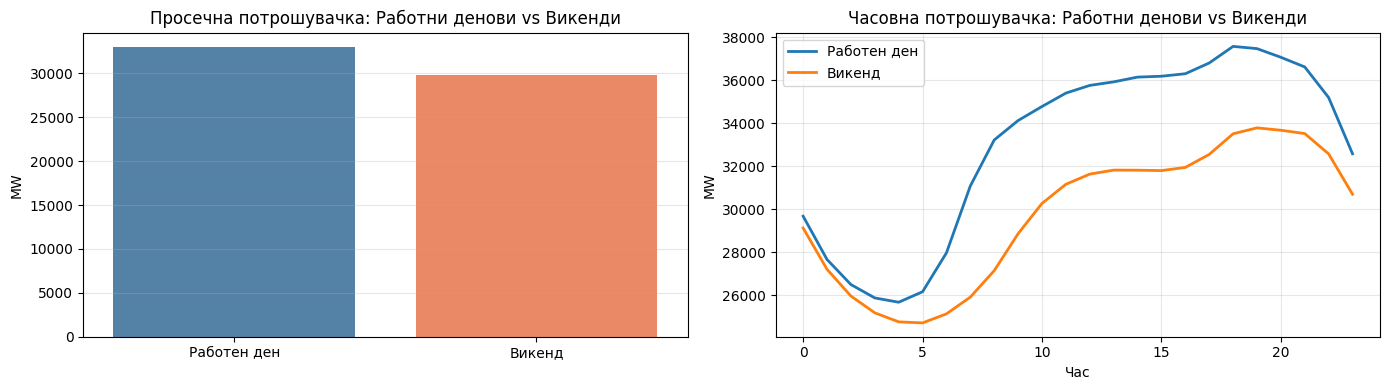

In [ ]:
df['is_weekend'] = df.index.dayofweek >= 5

# Average consumption: weekday vs weekend
weekend_avg = df.groupby('is_weekend')['PJME_MW'].mean()

# Plot 1: Overall comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.barplot(x=['Работен ден', 'Викенд'], y=weekend_avg.values, ax=axes[0], palette=['steelblue', 'coral'])
axes[0].set_title('Просечна потрошувачка: Работни денови vs Викенди')
axes[0].set_ylabel('MW')
axes[0].grid(axis='y', alpha=0.3)

# Plot 2: Hourly pattern comparison
hourly_weekend = df.groupby(['hour', 'is_weekend'])['PJME_MW'].mean().unstack()
hourly_weekend.plot(kind='line', ax=axes[1], linewidth=2)
axes[1].set_title('Часовна потрошувачка: Работни денови vs Викенди')
axes[1].set_xlabel('Час')
axes[1].set_ylabel('MW')
axes[1].legend(['Работен ден', 'Викенд'])
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

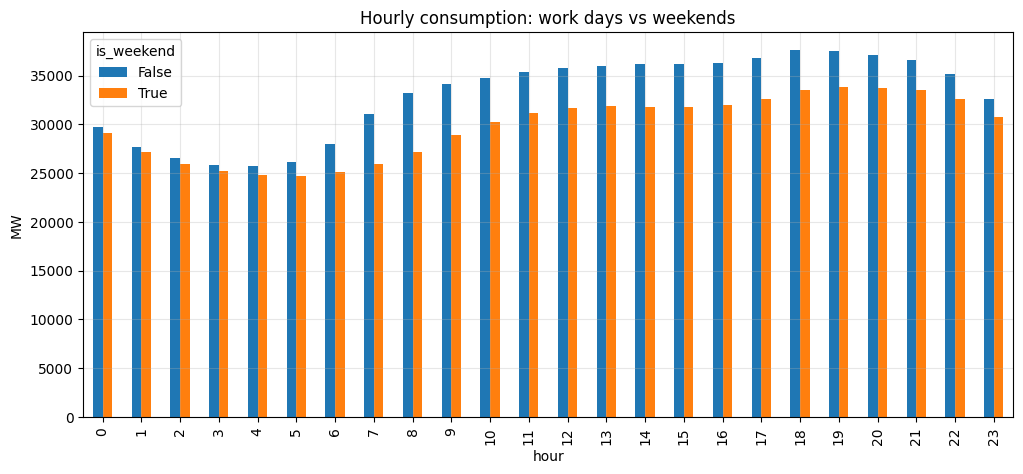

In [ ]:
hourly_weekend = df.groupby(['hour', 'is_weekend'])['PJME_MW'].mean().unstack()

hourly_weekend.plot(kind='bar', figsize=(12,5))
plt.title('Hourly consumption: work days vs weekends')
plt.ylabel('MW')
plt.grid(alpha=0.3)
plt.show()


Пониската потрошувачка за време на викендите е очекувана поради намалена индустриска и деловна активност.

###3.8 Лето vs Зима

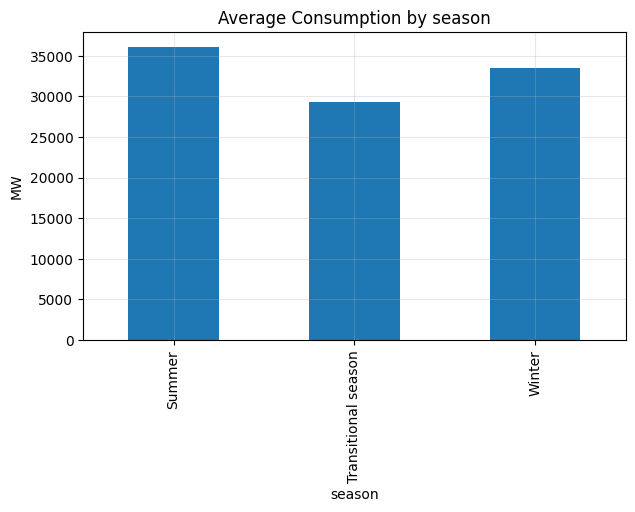

In [ ]:
def season(month):
    if month in [12,1,2]:
        return 'Winter'
    elif month in [6,7,8]:
        return 'Summer'
    else:
        return 'Transitional season'

df['season'] = df.index.month.map(season)

df.groupby('season')['PJME_MW'].mean().plot(
    kind='bar', figsize=(7,4)
)

plt.title('Average Consumption by season')
plt.ylabel('MW')
plt.grid(alpha=0.3)
plt.show()
df = df.drop(columns=['season'], errors='ignore')

Се забележува повисока потрошувачка во лето и зима, што може да се поврзе со користење на клима уреди и системи за греење.

## 4. Декомпозиција на временската серија

Со сезонска декомпозиција ја делиме серијата на:


* Тренд – долгорочно движење на потрошувачката
* Сезоналност – повторливи дневни шаблони (24 часа)
* Резидуали – случајни отстапувања

###4.1 Дневна сезоналност


🔄 TIME SERIES DECOMPOSITION

📊 Decomposition with daily seasonality (24 hours)...


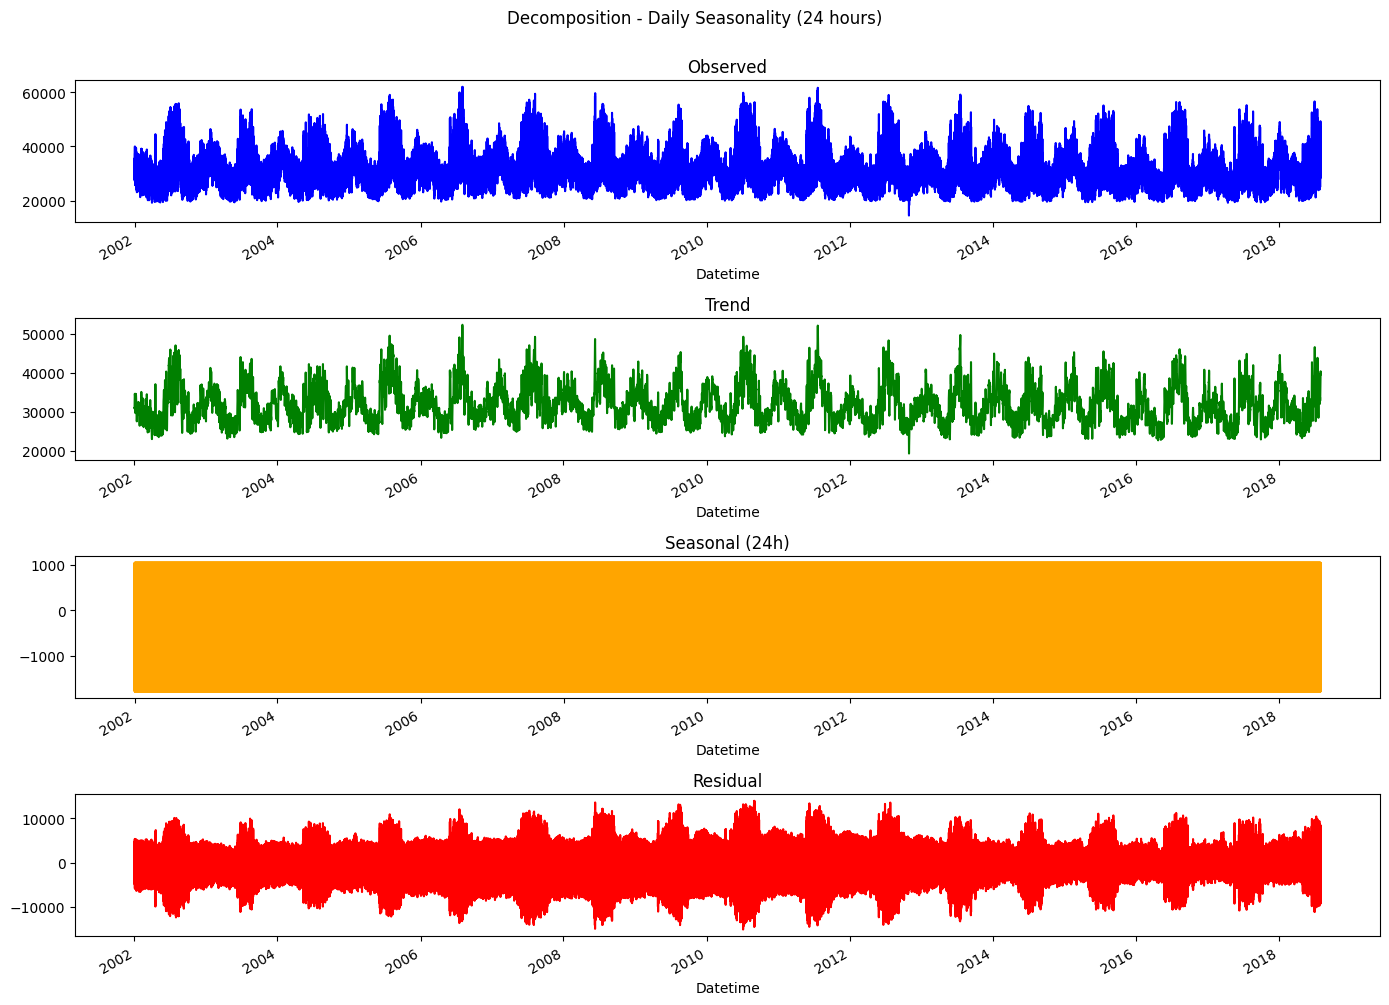

In [ ]:
print("\n" + "="*60)
print("🔄 TIME SERIES DECOMPOSITION")
print("="*60)

# Daily seasonality (period=24 hours)
print("\n📊 Decomposition with daily seasonality (24 hours)...")
decomposition_daily = seasonal_decompose(df['PJME_MW'], model='additive', period=24)

fig, axes = plt.subplots(4, 1, figsize=(14, 10))
decomposition_daily.observed.plot(ax=axes[0], title='Observed', color='blue')
decomposition_daily.trend.plot(ax=axes[1], title='Trend', color='green')
decomposition_daily.seasonal.plot(ax=axes[2], title='Seasonal (24h)', color='orange')
decomposition_daily.resid.plot(ax=axes[3], title='Residual', color='red')
plt.suptitle('Decomposition - Daily Seasonality (24 hours)', y=1.001)
plt.tight_layout()
plt.show()

###4.2 Неделна сезоналност

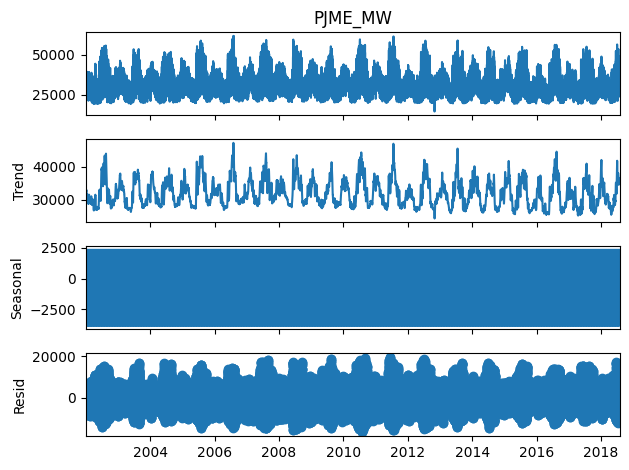

In [ ]:
decomposition_weekly = seasonal_decompose(
    df['PJME_MW'], model='additive', period=168)
decomposition_weekly.plot()
plt.show()

## 5. Основни (Baseline) модели

Основните модели служат како референтна точка за споредба со покомплексни методи.


### 5.1 Train/Test Split


In [ ]:
df['lag_1'] = df['PJME_MW'].shift(1)

In [ ]:
print("\n" + "="*60)
print("📚 PREPARE DATA FOR ALL MODELS")
print("="*60)

# Use last HORIZON hours as test set
split_date = df.index[-HORIZON]
train_ts = df[df.index < split_date].copy()
test_ts = df[df.index >= split_date].copy()

print(f"\nTrain: {train_ts.shape}")
print(f"  Range: {train_ts.index.min()} to {train_ts.index.max()}")
print(f"\nTest: {test_ts.shape}")
print(f"  Range: {test_ts.index.min()} to {test_ts.index.max()}")

y_test = test_ts['PJME_MW'].values


📚 PREPARE DATA FOR ALL MODELS

Train: (145194, 6)
  Range: 2002-01-01 01:00:00 to 2018-07-27 00:00:00

Test: (168, 6)
  Range: 2018-07-27 01:00:00 to 2018-08-03 00:00:00


In [ ]:
print("\n" + "="*60)
print("🧠 BASELINE MODELS")
print("="*60)

# Naive model: last value repeats
naive_pred = np.full(len(test_ts), train_ts['PJME_MW'].iloc[-1])

# Seasonal Naive (24-hour lag): same hour yesterday
seasonal_naive_pred = train_ts['PJME_MW'].iloc[-24:].values
seasonal_naive_pred = np.tile(seasonal_naive_pred, (len(test_ts) // 24) + 1)[:len(test_ts)]

print(f"\nNaive prediction (last value): {naive_pred[0]:.2f} MW")
print(f"Seasonal Naive (24h lag) first value: {seasonal_naive_pred[0]:.2f} MW")


🧠 BASELINE MODELS

Naive prediction (last value): 35742.00 MW
Seasonal Naive (24h lag) first value: 30293.00 MW


In [ ]:
print("\n" + "="*60)
print("📊 BASELINE MODEL EVALUATION")
print("="*60)

metrics = {}

metrics["Naive"] = calculate_metrics(y_test, naive_pred, "Naive (Lag-1)")
metrics["Seasonal Naive"] = calculate_metrics(y_test, seasonal_naive_pred, "Seasonal Naive (Lag-24)")


📊 BASELINE MODEL EVALUATION

Naive (Lag-1) Performance:
  RMSE: 6,719.73
  MAE:  5,712.10
  MAPE: 16.74%

Seasonal Naive (Lag-24) Performance:
  RMSE: 4,443.84
  MAE:  3,578.15
  MAPE: 10.20%


## 6. Класични модели (SARIMA и Prophet)

Класичните модели за временски серии експлицитно ја моделираат сезоналноста и трендот.




🔮 PROPHET MODEL

Prophet Performance:
  RMSE: 3,910.89
  MAE:  3,320.30
  MAPE: 9.80%


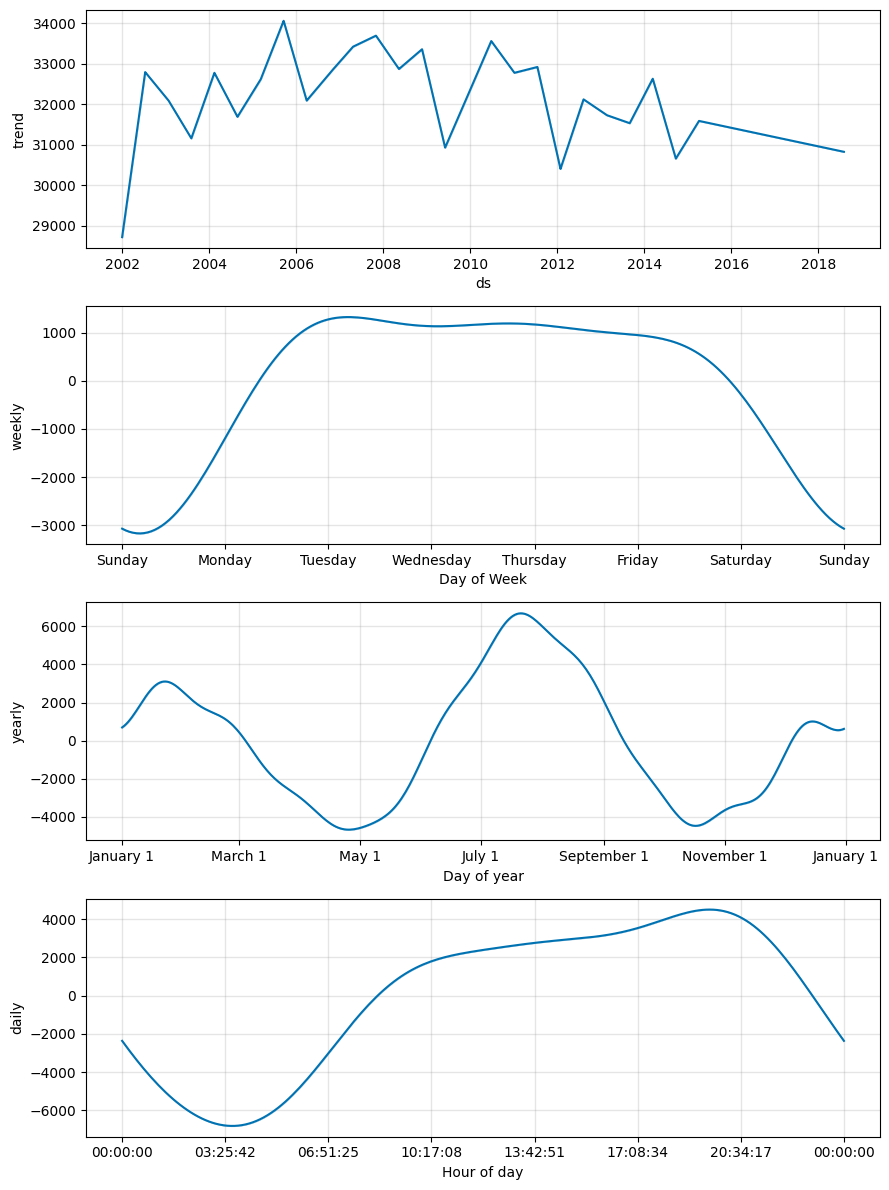


✅ Prophet training complete


In [ ]:
print("\n" + "="*60)
print("🔮 PROPHET MODEL")
print("="*60)

# Prepare data for Prophet
prophet_df = train_ts[['PJME_MW']].reset_index()
prophet_df.columns = ['ds', 'y']

# Train Prophet with hourly seasonality
prophet_model = Prophet(
    daily_seasonality=True,
    weekly_seasonality=True,
    yearly_seasonality=True
)
prophet_model.fit(prophet_df)

# Forecast
future = prophet_model.make_future_dataframe(periods=HORIZON, freq='h')
forecast = prophet_model.predict(future)

prophet_pred = forecast['yhat'].iloc[-HORIZON:].values

metrics["Prophet"] = calculate_metrics(y_test, prophet_pred, "Prophet")

# Plot components
prophet_model.plot_components(forecast)
plt.tight_layout()
plt.show()

print("\n✅ Prophet training complete")


In [ ]:
train_daily = train_ts['PJME_MW'].resample('D').mean()
test_daily = test_ts['PJME_MW'].resample('D').mean()

print("Daily points:", len(train_daily))


Daily points: 6052


In [ ]:
sarima_model = SARIMAX(
    train_daily,
    order=(1,1,1),
    seasonal_order=(1,1,1,7)  # weekly seasonality
)

sarima_fit = sarima_model.fit(disp=False)
sarima_pred = sarima_fit.forecast(steps=len(test_daily))


## 7. Машинско учење

Моделите од машинско учење не ја земаат предвид временската зависност директно, па користиме lag features, rolling features и time features.

In [ ]:
print("\n" + "="*60)
print("🤖 MACHINE LEARNING MODELS")
print("="*60)

def create_lag_features(data, n_lags=24):
    """Create comprehensive lag and time features for ML models"""
    df_ml = data.copy()

    # Lag features (1, 24, 168 hours)
    df_ml['lag_1'] = df_ml['PJME_MW'].shift(1)
    df_ml['lag_24'] = df_ml['PJME_MW'].shift(24)
    df_ml['lag_168'] = df_ml['PJME_MW'].shift(168)

    # Rolling statistics
    df_ml['rolling_mean_24'] = df_ml['PJME_MW'].shift(1).rolling(24).mean()
    df_ml['rolling_std_24'] = df_ml['PJME_MW'].shift(1).rolling(24).std()
    df_ml['rolling_mean_168'] = df_ml['PJME_MW'].shift(1).rolling(168).mean()

    # Time features (already exist from EDA)
    # hour, dayofweek, month, is_weekend are already in df

    # Drop NaN from lags
    df_ml = df_ml.dropna()

    return df_ml

# Create features
df_ml = create_lag_features(df, N_LAGS)

# Split
train_ml = df_ml[df_ml.index < split_date]
test_ml = df_ml[df_ml.index >= split_date]

# Separate features and target
feature_cols = ['lag_1', 'lag_24', 'lag_168',
                'rolling_mean_24', 'rolling_std_24', 'rolling_mean_168',
                'hour', 'dayofweek', 'month', 'is_weekend']

X_train = train_ml[feature_cols]
y_train_ml = train_ml['PJME_MW']
X_test = test_ml[feature_cols]
y_test_ml = test_ml['PJME_MW']

print(f"\nML Train: {X_train.shape}, ML Test: {X_test.shape}")
print(f"Features used: {feature_cols}")



🤖 MACHINE LEARNING MODELS

ML Train: (145026, 10), ML Test: (168, 10)
Features used: ['lag_1', 'lag_24', 'lag_168', 'rolling_mean_24', 'rolling_std_24', 'rolling_mean_168', 'hour', 'dayofweek', 'month', 'is_weekend']


In [ ]:
print("\n🚀 Training Random Forest...")

rf = RandomForestRegressor(
    n_estimators=RF_N_ESTIMATORS,
    max_depth=RF_MAX_DEPTH,
    random_state=RF_RANDOM_STATE,
    n_jobs=-1
)
rf.fit(X_train, y_train_ml)
rf_pred = rf.predict(X_test)

metrics["Random Forest"] = calculate_metrics(y_test_ml, rf_pred, "Random Forest")


🚀 Training Random Forest...

Random Forest Performance:
  RMSE: 398.97
  MAE:  296.66
  MAPE: 0.81%


In [ ]:
print("\n🚀 Training XGBoost...")

xgb_model = XGBRegressor(
    n_estimators=XGB_N_ESTIMATORS,
    learning_rate=XGB_LEARNING_RATE,
    max_depth=XGB_MAX_DEPTH,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
xgb_model.fit(X_train, y_train_ml)
xgb_pred = xgb_model.predict(X_test)

metrics["XGBoost"] = calculate_metrics(y_test_ml, xgb_pred, "XGBoost")


🚀 Training XGBoost...

XGBoost Performance:
  RMSE: 422.41
  MAE:  330.06
  MAPE: 0.89%


In [ ]:
print("\n🚀 Training LightGBM...")

lgbm = LGBMRegressor(
    n_estimators=LGBM_N_ESTIMATORS,
    learning_rate=LGBM_LEARNING_RATE,
    max_depth=LGBM_MAX_DEPTH,
    random_state=42,
    verbose=-1
)
lgbm.fit(X_train, y_train_ml)
lgbm_pred = lgbm.predict(X_test)

metrics["LightGBM"] = calculate_metrics(y_test_ml, lgbm_pred, "LightGBM")


🚀 Training LightGBM...

LightGBM Performance:
  RMSE: 395.76
  MAE:  305.22
  MAPE: 0.83%


##8. Евалуација на моделите

Моделите се споредуваат со следните метрики:

* MAE (Mean Absolute Error) – просечна апсолутна грешка
* RMSE (Root Mean Squared Error) – чувствителна на големи грешки
* MAPE (Mean Absolute Percentage Error)– просечна апсолутна процентуална грешка
* R² (Coefficient of Determination) – варијанса


In [ ]:
def mape(y_true, y_pred):
  return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

def evaluate(y_true, y_pred):
  return {
      'MAE': mean_absolute_error(y_true, y_pred),
      'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
      'MAPE': mape(y_true, y_pred),
      'R2': r2_score(y_true, y_pred)
  }

In [ ]:
print("\n" + "="*60)
print("📊 FINAL RESULTS - ALL MODELS COMPARISON")
print("="*60)

results_df = pd.DataFrame(metrics).T
results_df = results_df.sort_values("MAPE")

print("\n" + results_df.to_string())

print("\n🏆 Best Model (by MAPE):")
best_model = results_df.index[0]
best_mape = results_df.loc[best_model, 'MAPE']
print(f"   {best_model}: {best_mape:.2f}%")


📊 FINAL RESULTS - ALL MODELS COMPARISON

                       RMSE          MAE       MAPE
Random Forest    398.971611   296.655143   0.805986
LightGBM         395.760240   305.215859   0.833284
XGBoost          422.407948   330.061419   0.891635
Prophet         3910.890274  3320.297430   9.800646
Seasonal Naive  4443.837730  3578.148810  10.201075
Naive           6719.734327  5712.095238  16.740305

🏆 Best Model (by MAPE):
   Random Forest: 0.81%


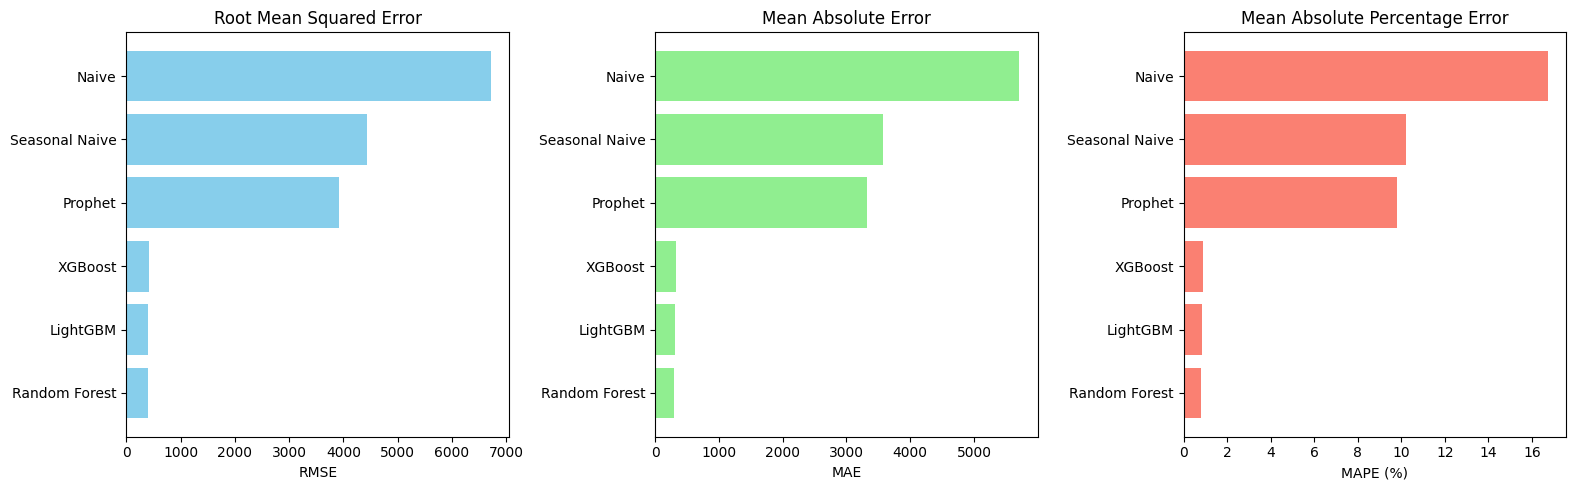

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

models = results_df.index
rmse_vals = results_df["RMSE"].values
mae_vals = results_df["MAE"].values
mape_vals = results_df["MAPE"].values

axes[0].barh(models, rmse_vals, color='skyblue')
axes[0].set_xlabel("RMSE")
axes[0].set_title("Root Mean Squared Error")

axes[1].barh(models, mae_vals, color='lightgreen')
axes[1].set_xlabel("MAE")
axes[1].set_title("Mean Absolute Error")

axes[2].barh(models, mape_vals, color='salmon')
axes[2].set_xlabel("MAPE (%)")
axes[2].set_title("Mean Absolute Percentage Error")

plt.tight_layout()
plt.show()

###8.1 XGBoost – Actual vs Predicted


📈 XGBoost: Actual vs Predicted (Full Test Set)


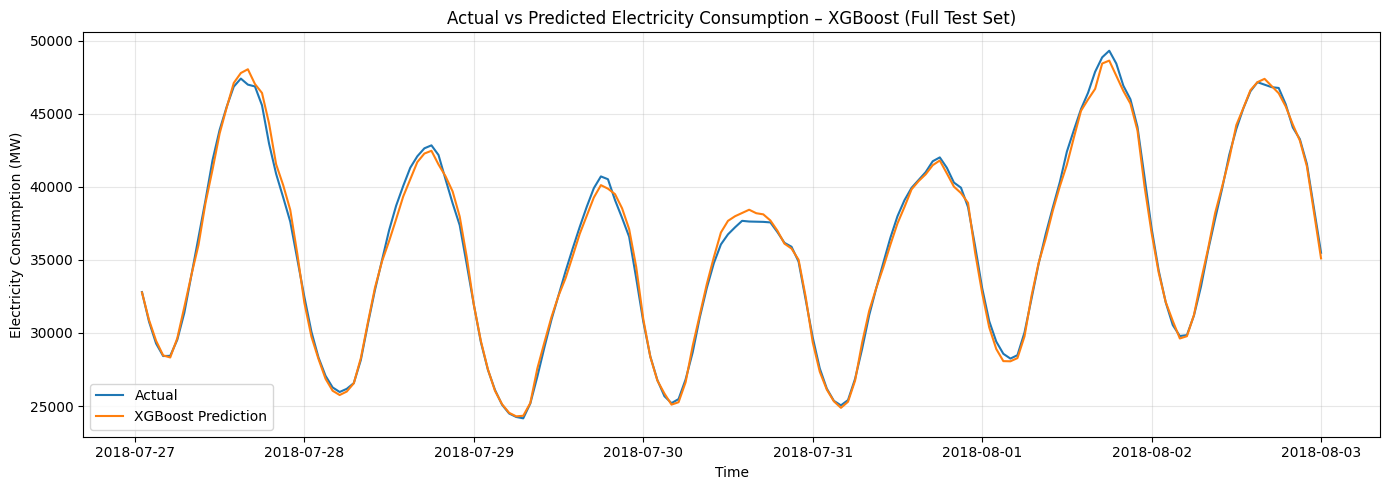

In [ ]:
print("\n📈 XGBoost: Actual vs Predicted (Full Test Set)")
time_index = test_ml.index  # ML test set index (168 points)

plt.figure(figsize=(14,5))
plt.plot(time_index, y_test_ml, label='Actual')  # ML actuals
plt.plot(time_index, xgb_pred, label='XGBoost Prediction')  # ML predictions
plt.legend()
plt.title('Actual vs Predicted Electricity Consumption – XGBoost (Full Test Set)')
plt.xlabel('Time')
plt.ylabel('Electricity Consumption (MW)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


XGBoost најпрецизно ги следи реалните вредности и ги фаќа дневните пикови и падови.

8.2 SARIMA – Actual vs Predicted


📈 SARIMA: Actual vs Predicted
SARIMA predictions length: 8


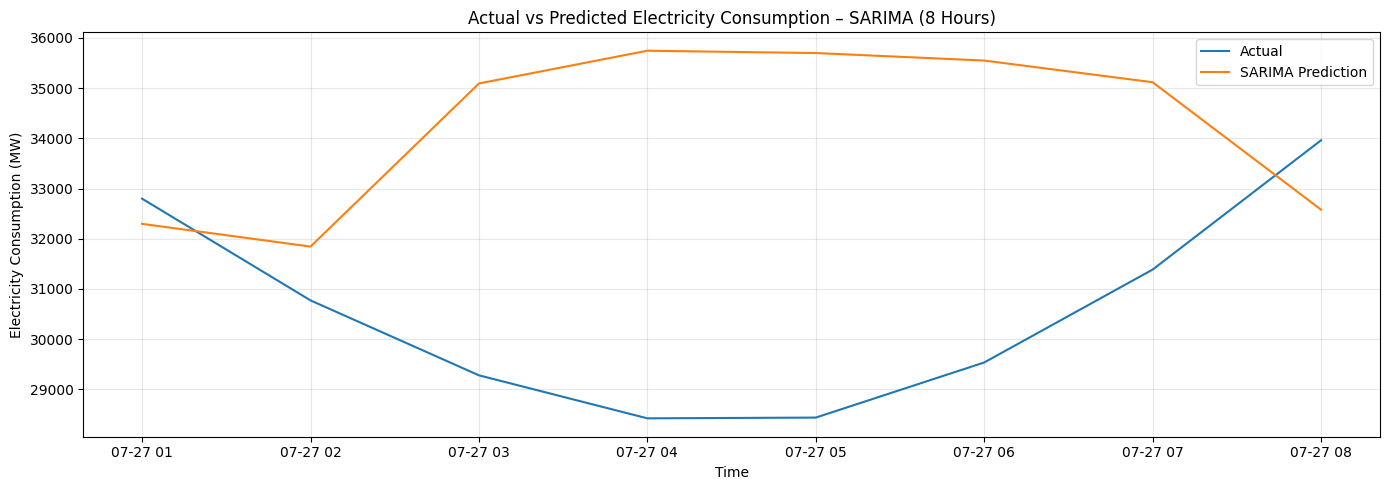

In [ ]:
print("\n📈 SARIMA: Actual vs Predicted")
print(f"SARIMA predictions length: {len(sarima_pred)}")

# Use FULL test set length (no slicing mismatch)
time_index = test_ts.index[:len(sarima_pred)]  # Match prediction length
plt.figure(figsize=(14,5))
plt.plot(time_index, test_ts['PJME_MW'][:len(sarima_pred)], label='Actual')
plt.plot(time_index, sarima_pred, label='SARIMA Prediction')
plt.legend()
plt.title(f'Actual vs Predicted Electricity Consumption – SARIMA ({len(sarima_pred)} Hours)')
plt.xlabel('Time')
plt.ylabel('Electricity Consumption (MW)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


SARIMA не успева да ја моделира сложената сезоналност на часовните податоци и покажува значителни отстапувања.

###8.3 Prophet – Actual vs Predicted


📈 Prophet: Actual vs Predicted


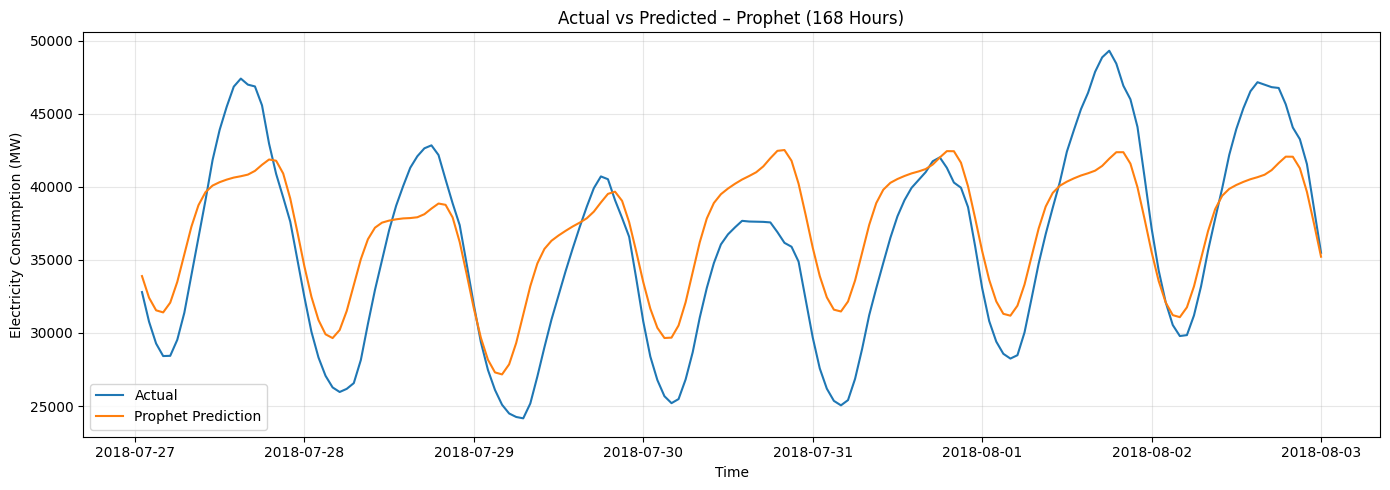

In [ ]:
print("\n📈 Prophet: Actual vs Predicted")
time_index = test_ts.index[:HORIZON]  # Matches your train_ts/test_ts split
plt.figure(figsize=(14,5))
plt.plot(time_index, test_ts['PJME_MW'][:HORIZON], label='Actual')  # Use test_ts
plt.plot(time_index, prophet_pred, label='Prophet Prediction')      # Full prediction length
plt.legend()
plt.title(f'Actual vs Predicted – Prophet ({HORIZON} Hours)')
plt.xlabel('Time')
plt.ylabel('Electricity Consumption (MW)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Prophet добро го идентификува долгорочниот тренд и повторливите сезонски обрасци, но не успева прецизно да ги следи брзите и ненадејни промени во часовната потрошувачка.

###8.4 Финална споредба на грешки (MAE, RMSE, MAPE)

In [ ]:
# results_df.set_index('Model')[['MAE','RMSE', 'MAPE']].plot(kind='bar', figsize=(10,5))
# plt.title('Model Error Comparison')
# plt.ylabel('Error (MW)')
# plt.tight_layout()
# plt.show()


📈 PREDICTION COMPARISON - VISUAL ANALYSIS
test_ts length: 168
prophet_pred length: 168
sarima_pred length: 8
rfpred length: N/A
✅ Using plot_hours = 8


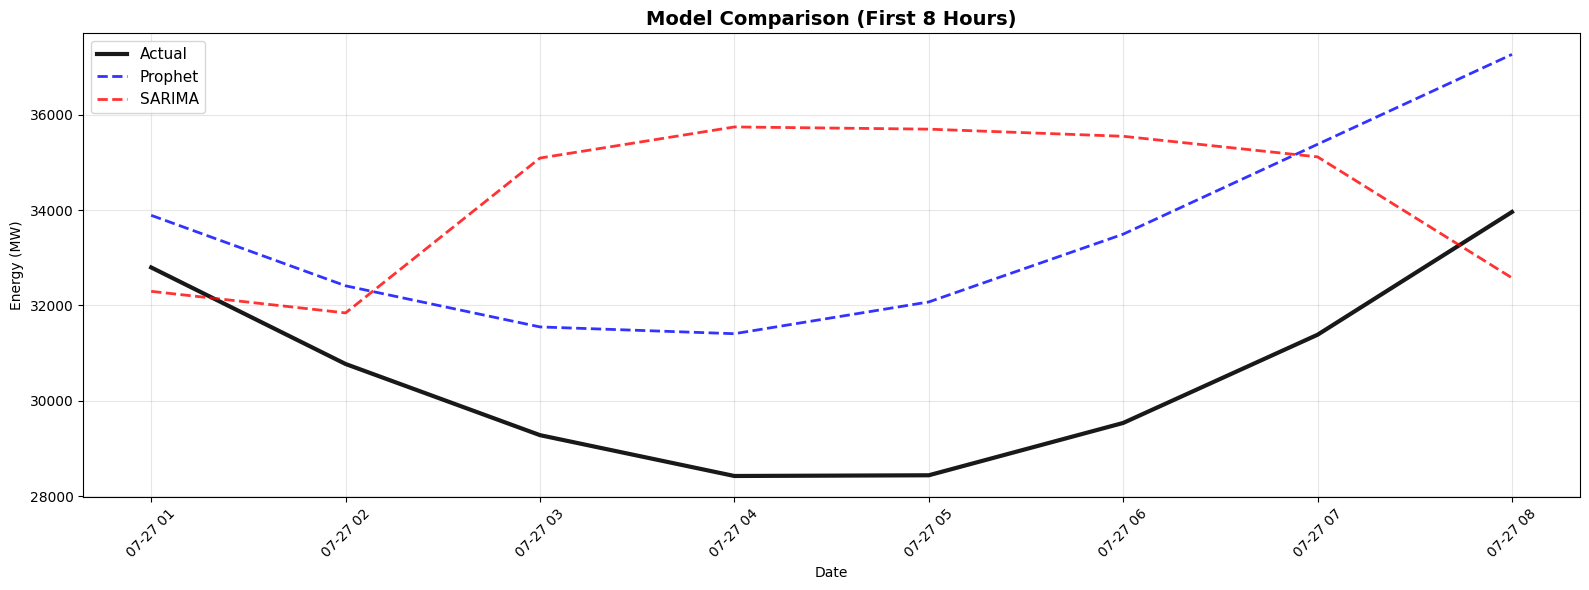

In [ ]:
print("\n" + "="*60)
print("📈 PREDICTION COMPARISON - VISUAL ANALYSIS")
print("="*60)

# 🔍 DEBUG: Check all lengths FIRST
print(f"test_ts length: {len(test_ts)}")
print(f"prophet_pred length: {len(prophet_pred)}")
print(f"sarima_pred length: {len(sarima_pred)}")
print(f"rfpred length: {len(rfpred) if 'rfpred' in globals() else 'N/A'}")

# ✅ FIX: Use SHORTEST common length
plot_hours = min([
    len(test_ts),
    len(prophet_pred),
    len(sarima_pred)
])

print(f"✅ Using plot_hours = {plot_hours}")

fig, ax = plt.subplots(figsize=(16, 6))

# Actual values
ax.plot(test_ts.index[:plot_hours], test_ts['PJME_MW'][:plot_hours],
        label='Actual', linewidth=3, color='black', alpha=0.9)

# Prophet (should work)
ax.plot(test_ts.index[:plot_hours], prophet_pred[:plot_hours],
        label='Prophet', linewidth=2, alpha=0.8, linestyle='--', color='blue')

# SARIMA (now matches length)
ax.plot(test_ts.index[:plot_hours], sarima_pred[:plot_hours],
        label='SARIMA', linewidth=2, alpha=0.8, linestyle='--', color='red')

# ML models (if they exist)
if 'rfpred' in globals():
    ml_hours = min(plot_hours, len(rfpred))
    ax.plot(test_ml.index[:ml_hours], rfpred[:ml_hours],
            label='Random Forest', linewidth=2, alpha=0.8, color='green')

ax.legend(loc='upper left', fontsize=11)
ax.set_title(f'Model Comparison (First {plot_hours} Hours)', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Energy (MW)')
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


##9. Заклучок

Во овој проект беше извршена анализа и споредба на повеќе модели за предвидување на часовната потрошувачка на електрична енергија користејќи го множеството PJME Hourly Energy Consumption. Анализата опфати базични модели, класични модели за временски серии и модели од машинско учење со дополнителни временски и lag карактеристики.

Резултатите покажуваат дека едноставните базични модели служат како корисна референтна точка, класичните модели обезбедуваат подобро разбирање на трендот и сезоналноста, додека моделите од машинско учење постигнуваат значително повисока точност во предвидувањето. Особено се истакнува Random Forest моделот, кој покажува најдобри резултати според сите евалуациски метрики.

###9.1 Naive (Lag-1)

Naive моделот ја користи последната позната вредност како предвидување за идниот период. Како наједноставен пристап, тој покажува најлоши резултати меѓу сите модели, со високи MAE, RMSE и MAPE вредности.

###9.2 Seasonal Naive (Lag-24)

Seasonal Naive ја користи вредноста од истиот час претходниот ден како предвидување. Овој модел покажува значително подобри резултати во споредба со едноставниот Naive модел, што потврдува дека часовната потрошувачка на електрична енергија има силна дневна сезоналност.

###9.3 Prophet

Prophet покажува слични перформанси на Seasonal Naive моделот, но не успева значително да ги подобри резултатите. Иако добро го идентификува долгорочниот тренд и сезоналните компоненти, Prophet не е доволно прецизен при фаќање на наглите и брзи промени во часовната потрошувачка.

###9.4 Random Forest

Random Forest моделот постигнува најдобри резултати меѓу сите тестирани модели. Kористи lag карактеристики, rolling статистики и временски карактеристики и успешно ги фаќа нелинеарните односи и сложените обрасци во податоците. Random Forest е најпрецизниот модел за ова податочно множество

###9.5 XGBoost

XGBoost моделот постигнува добри резултати и успешно ги следи дневните обрасци на потрошувачка, но според сите евалуациски метрики заостанува зад Random Forest и LightGBM.

###9.6 LightGBM

LightGBM моделот постигнува резултати слични на XGBoost, со малку подобри перформанси. Моделот е ефикасен и брз за обука, но во овој конкретен случај не успева целосно да ја надмине точноста на Random Forest.

In [ ]:
# ========================================
# 🎯 EXPORT RESULTS FOR COMPARISON
# ========================================

print("\n" + "="*70)
print("📊 ENERGY - FINAL EXPORT")
print("="*70)

# 🔍 DEBUG: Check what's in metrics
print("Available metrics:", list(metrics.keys()))

# ✅ SAFE: Only include models that exist
model_names = ['Naive', 'Seasonal Naive', 'Prophet', 'SARIMA', 'Random Forest', 'XGBoost', 'LightGBM']
available_models = [name for name in model_names if name in metrics]

print(f"✅ Using {len(available_models)} models: {available_models}")

# Build results dynamically
data = {'model': [], 'RMSE': [], 'MAE': [], 'MAPE': []}
for model in available_models:
    data['model'].append(model)
    data['RMSE'].append(metrics[model]['RMSE'])
    data['MAE'].append(metrics[model]['MAE'])
    data['MAPE'].append(metrics[model]['MAPE'])

results = pd.DataFrame(data)

# Round for readability
results['RMSE'] = results['RMSE'].round(2)
results['MAE'] = results['MAE'].round(2)
results['MAPE'] = results['MAPE'].round(2)

# Sort by MAPE
results_sorted = results.sort_values('MAPE').reset_index(drop=True)

print("\n📈 Final Results (sorted by MAPE):")
print(results_sorted.to_string(index=False))

# Highlight winner
if len(results_sorted) > 0:
    best = results_sorted.iloc[0]
    print(f"\n🏆 WINNER: {best['model']}")
    print(f"   MAPE: {best['MAPE']:.2f}%")
    print(f"   MAE: {best['MAE']:.2f}")
    print(f"   RMSE: {best['RMSE']:.2f}")

    # Improvement over baseline (if exists)
    if 'Naive' in metrics:
        baseline_mape = metrics["Naive"]['MAPE']
        improvement = ((baseline_mape - best['MAPE']) / baseline_mape) * 100
        print(f"\n📊 Improvement over Naive: +{improvement:.1f}%")

# Save to CSV
filename = 'energy_metrics.csv'
results.to_csv(filename, index=False)
print(f"\n✅ Saved to: {filename}")

try:
    from google.colab import files
    files.download(filename)
except:
    print("📥 Download manually or run in Colab")

print("\n" + "="*70)
print("🎉 ENERGY = COMPLETE!")
print("="*70)



📊 ENERGY - FINAL EXPORT
Available metrics: ['Naive', 'Seasonal Naive', 'Prophet', 'Random Forest', 'XGBoost', 'LightGBM']
✅ Using 6 models: ['Naive', 'Seasonal Naive', 'Prophet', 'Random Forest', 'XGBoost', 'LightGBM']

📈 Final Results (sorted by MAPE):
         model    RMSE     MAE  MAPE
 Random Forest  398.97  296.66  0.81
      LightGBM  395.76  305.22  0.83
       XGBoost  422.41  330.06  0.89
       Prophet 3910.89 3320.30  9.80
Seasonal Naive 4443.84 3578.15 10.20
         Naive 6719.73 5712.10 16.74

🏆 WINNER: Random Forest
   MAPE: 0.81%
   MAE: 296.66
   RMSE: 398.97

📊 Improvement over Naive: +95.2%

✅ Saved to: energy_metrics.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


🎉 ENERGY = COMPLETE!
